### **Instrucciones Generales**

* Accede a Teams para descargar el archivo CSV que está subido en la tarea.
* Utiliza los hiperparámetros que consideres oportunos para el modelo.





---

**Pregunta 1: Preparación y análisis (1 punto)**

* Importar las librerías necesarias.


* Cargar el archivo `.csv`.


* Analizar el conjunto de datos: ¿Cuántas filas y columnas tiene?.


* Comprobar si el dataset está balanceado.


* Crear un gráfico que muestre cuántos comentarios hay por cada sentimiento.
---




In [2]:
import csv
import tensorflow as tf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from nltk.corpus import stopwords
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Embedding, LSTM

In [3]:
import nltk

nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [4]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [5]:
df = pd.read_csv('/content/drive/MyDrive/Datasets/PIA/UD7/YoutubeCommentsDataSet.csv')
df.head()

,Comment,Sentiment
0,lets not forget that apple pay in 2014 require...,neutral
1,here in nz 50 of retailers don’t even have con...,negative
2,i will forever acknowledge this channel with t...,positive
3,whenever i go to a place that doesn’t take app...,negative
4,apple pay is so convenient secure and easy to ...,positive


In [6]:
df.info()

# Filas 18408 - Columnas 2

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18408 entries, 0 to 18407
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Comment    18364 non-null  object
 1   Sentiment  18408 non-null  object
dtypes: object(2)
memory usage: 287.8+ KB


In [7]:
df.value_counts('Sentiment')

# No parece muy balanceado, tiene muchos sentimientos positivos y pocos sentimientos negativos

,count
Sentiment,
positive,11432
neutral,4638
negative,2338


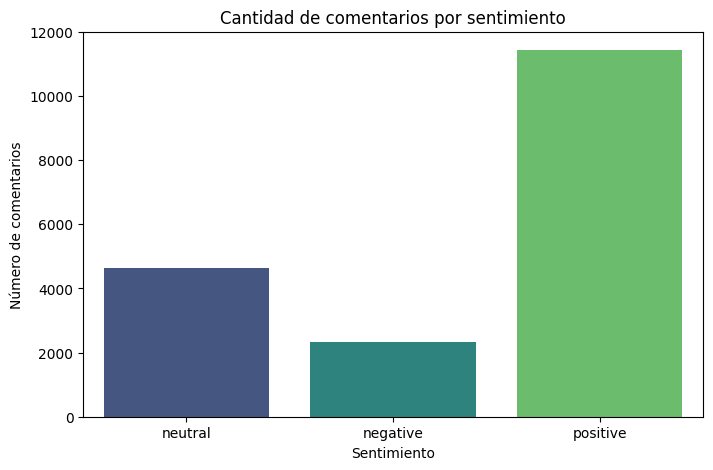

In [8]:
# Configurar el tamaño del gráfico
plt.figure(figsize=(8, 5))

# Crear el gráfico de barras contando los valores de la columna 'Sentiment'
sns.countplot(data=df, x='Sentiment', hue='Sentiment', palette='viridis', legend=False)

# Añadir título y etiquetas a los ejes
plt.title('Cantidad de comentarios por sentimiento')
plt.xlabel('Sentimiento')
plt.ylabel('Número de comentarios')

# Mostrar el gráfico
plt.show()

---

**Pregunta 2: Preprocesamiento y limpieza del texto (1 punto)**

* Convertir todo el texto a minúsculas.


* Eliminar los signos de puntuación.


* Eliminar los números.


* Eliminar las *stopwords* (palabras vacías).


* Aplicar esta limpieza de texto a todos los comentarios del dataset.

---


In [9]:
df['Comment'].isna().sum()

np.int64(44)

In [10]:
# Convertir a minúsculas
df['Comment'] = df['Comment'].str.lower()

# Eliminar signos de puntuación
df['Comment'] = df['Comment'].str.replace(r'[^\w\s]', '', regex=True)

# Eliminar números
df['Comment'] = df['Comment'].str.replace(r'\d+', '', regex=True)

# Eliminar stopwords
stop_words = set(stopwords.words('english'))

df['Comment'] = df['Comment'].fillna('')

df['Comment'] = df['Comment'].apply(
    lambda x: " ".join(word for word in x.split() if word not in stop_words)
)
df.head()

,Comment,Sentiment
0,lets forget apple pay required brand new iphon...,neutral
1,nz retailers dont even contactless credit card...,negative
2,forever acknowledge channel help lessons ideas...,positive
3,whenever go place doesnt take apple pay doesnt...,negative
4,apple pay convenient secure easy use used kore...,positive


---

**Pregunta 3 (0,5 puntos)**

* Transformar las etiquetas de sentimiento en valores numéricos.

---



In [11]:
# 1. Definir el diccionario con la equivalencia numérica
mapeo_sentimientos = {
    'negative': 0,
    'neutral': 1,
    'positive': 2
}

# 2. Aplicar el mapeo
df['Sentiment'] = df['Sentiment'].map(mapeo_sentimientos)

# 3. Ver el cambio
print(df['Sentiment'].value_counts())

Sentiment
2    11432
1     4638
0     2338
Name: count, dtype: int64


---

**Pregunta 4 (1 punto)**

* Tokenizar los textos.


* Imprimir las 10 primeras palabras del vocabulario.


* Padenizar (aplicar *padding*) a las secuencias para que tengan la misma longitud.
---




In [12]:
stats = df['Comment'].str.split().str.len().describe()
print(stats)

count    18408.000000
mean        17.986365
std         24.685861
min          0.000000
25%          7.000000
50%         12.000000
75%         21.000000
max        918.000000
Name: Comment, dtype: float64


In [13]:
vocab_size = 5000
max_length = 30
embedding_dim = 64
oov_tok = "<OOV>"
trunc_type = 'post'
padding_type = 'post'

##############

tokenizer = Tokenizer(num_words=vocab_size, oov_token=oov_tok)
tokenizer.fit_on_texts(df['Comment'])

word_index = tokenizer.word_index

In [14]:
dict(list(word_index.items())[0:10])

{'<OOV>': 1,
 'like': 2,
 'love': 3,
 'im': 4,
 'one': 5,
 'video': 6,
 'really': 7,
 'time': 8,
 'thank': 9,
 'great': 10}

---

**Pregunta 5 (1 punto)**

* Dividir el conjunto de datos: un 80% para el conjunto de entrenamiento y un 20% para el conjunto de prueba.


* Definir la arquitectura de un modelo LSTM bidireccional.

---



In [15]:
from sklearn.model_selection import train_test_split

train_sentences, test_sentences, train_labels, test_labels = train_test_split(
    df['Comment'],
    df['Sentiment'],
    test_size=0.2,
    random_state=42
)

print(f"Entrenamiento: {len(train_sentences)} | Prueba: {len(test_sentences)}")

Entrenamiento: 14726 | Prueba: 3682


In [16]:
train_sequences = tokenizer.texts_to_sequences(train_sentences)
train_padded = pad_sequences(train_sequences, maxlen=max_length, padding='post', truncating='post')

test_sequences = tokenizer.texts_to_sequences(test_sentences)
test_padded = pad_sequences(test_sequences, maxlen=max_length, padding='post', truncating='post')

In [17]:
from tensorflow.keras.callbacks import EarlyStopping

# 1. Definimos la parada anticipada
early_stop = EarlyStopping(
    monitor='val_loss',       # Vigilamos el error de validación
    patience=3,               # Si no mejora en 3 épocas, paramos
    restore_best_weights=True # Recupera el modelo de la mejor época (ej. la época 2)
)

model = tf.keras.Sequential([
    # Capa de entrada con las dimensiones
    tf.keras.layers.Embedding(vocab_size, embedding_dim),

    # LSTM Bidireccional con recurrent_dropout
    tf.keras.layers.Bidirectional(tf.keras.layers.LSTM(embedding_dim,
                                                       return_sequences=False,
                                                       recurrent_dropout=0.2)),

    # Capas densas para clasificar
    tf.keras.layers.Dense(32, activation='relu'),
    tf.keras.layers.Dropout(0.5), # Para evitar el sobreajuste

    # Capa de salida (Asumiendo clasificación binaria: Positivo/Negativo -> sigmoid)
    # Si tienes más de 2 categorías, usamos 'softmax' y cambiamos
    # el 1 por el número de etiquetas.
    tf.keras.layers.Dense(3, activation='softmax')
])

---

**Pregunta 6 (1 punto)**

* Compilar el modelo.


* Entrenar el modelo utilizando los datos de validación (`validation_data`).

---



In [18]:
# Binaria -> binary_crossentropy
# Clasificación -> sparse_categorical_crossentropy

model.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [19]:
# 1. Obtenemos las frecuencias de cada clase dinámicamente
counts = df['Sentiment'].value_counts()

# 2. Calculamos el total y el número de clases
total_muestras = counts.sum()
num_clases = len(counts)

# 3. Calculamos los pesos (Fórmula: Total / (Num_Clases * Cantidad_por_Clase))
# Esto hace que la clase con menos ejemplos tenga un "peso" o importancia mayor
class_weight = {
    0: (1 / counts[0]) * (total_muestras / num_clases),
    1: (1 / counts[1]) * (total_muestras / num_clases),
    2: (1 / counts[2]) * (total_muestras / num_clases)
}

print("Pesos calculados para el modelo:")
for clase, peso in class_weight.items():
    print(f"Clase {clase}: {peso:.2f}")

Pesos calculados para el modelo:
Clase 0: 2.62
Clase 1: 1.32
Clase 2: 0.54


In [20]:
# Entrenamiento del modelo
history = model.fit(
    train_padded,               # Datos de entrenamiento
    train_labels,               # Etiquetas
    epochs=20,
    validation_data=(           # Datos para medir qué tan bien generaliza en cada vuelta
        test_padded,
        test_labels
    ),
    class_weight=class_weight,  # Para equilibrar el sesgo
    callbacks=[early_stop],     # Para parar anticipadamente
    verbose=2                   # Muestra una línea de resumen por cada epoch
)

Epoch 1/20
461/461 - 90s - 195ms/step - accuracy: 0.6241 - loss: 0.9052 - val_accuracy: 0.6749 - val_loss: 0.7126
Epoch 2/20
461/461 - 79s - 172ms/step - accuracy: 0.7489 - loss: 0.6564 - val_accuracy: 0.6670 - val_loss: 0.7541
Epoch 3/20
461/461 - 77s - 168ms/step - accuracy: 0.8004 - loss: 0.5240 - val_accuracy: 0.7135 - val_loss: 0.6584
Epoch 4/20
461/461 - 79s - 170ms/step - accuracy: 0.8362 - loss: 0.4345 - val_accuracy: 0.7224 - val_loss: 0.7683
Epoch 5/20
461/461 - 78s - 169ms/step - accuracy: 0.8568 - loss: 0.3676 - val_accuracy: 0.6871 - val_loss: 0.8179
Epoch 6/20
461/461 - 78s - 169ms/step - accuracy: 0.8786 - loss: 0.3089 - val_accuracy: 0.6812 - val_loss: 1.0601


---

**Pregunta 7 (0,5 puntos)**

* Representar gráficamente la precisión (*accuracy*) del entrenamiento y de la validación a lo largo de las épocas.
---




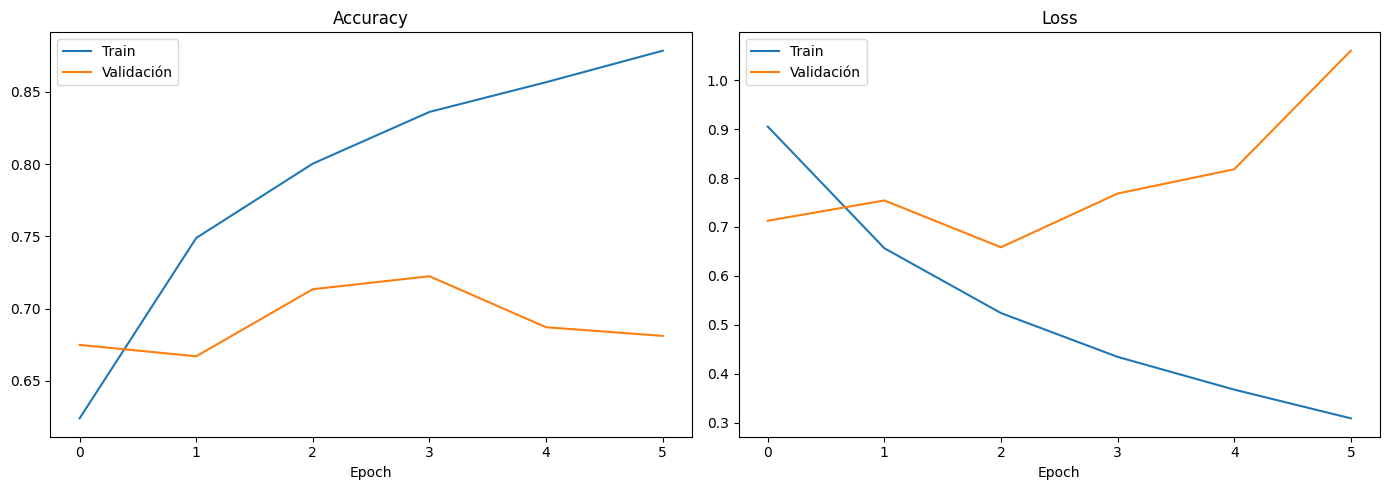

In [21]:
# Dibujar como ha ido el entrenamiento y la validación
def plot_history(history):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Accuracy
    axes[0].plot(history.history['accuracy'],     label='Train')
    axes[0].plot(history.history['val_accuracy'], label='Validación')
    axes[0].set_title('Accuracy')
    axes[0].set_xlabel('Epoch')
    axes[0].legend()

    # Loss
    axes[1].plot(history.history['loss'],     label='Train')
    axes[1].plot(history.history['val_loss'], label='Validación')
    axes[1].set_title('Loss')
    axes[1].set_xlabel('Epoch')
    axes[1].legend()

    plt.tight_layout()
    plt.show()

plot_history(history)

---

**Pregunta 8: Predicción de sentimiento (1,5 puntos)**

* Realizar una predicción de sentimiento para nuevos comentarios. Puedes usar los siguientes posibles ejemplos:


* "This video blew my mind, I wasn't expecting such quality!".


* "I thought it would be great, but honestly, I'm quite disappointed.".


* "Well, it wasn't bad, but at the same time, I wouldn't recommend it either".


* "After watching this, I feel like I completely wasted my time..".


* "I absolutely loved every single part of it, from the visuals to the explanations!".


* "It had potential, but it just didn't live up to my expectations.".

---





In [22]:
ejemplos = [
    "This video blew my mind, I wasn't expecting such quality!",
    "I thought it would be great, but honestly, I'm quite disappointed.",
    "Well, it wasn't bad, but at the same time, I wouldn't recommend it either",
    "After watching this, I feel like I completely wasted my time..",
    "I absolutely loved every single part of it, from the visuals to the explanations!",
    "It had potential, but it just didn't live up to my expectations."
]

In [23]:
secuencias_nuevas = tokenizer.texts_to_sequences(ejemplos)

secuencias_padded = pad_sequences(
    secuencias_nuevas,
    maxlen=max_length,
    padding='post',
    truncating='post'
)

In [24]:
predicciones = model.predict(secuencias_padded)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 539ms/step


In [25]:
clases_predichas = np.argmax(predicciones, axis=1)

In [26]:
print("-" * 50)
print("RESULTADOS DE LAS PREDICCIONES:")
print("-" * 50)

diccionario_sentimientos = {
    0: "Negativo",
    1: "Neutral",
    2: "Positivo"
}

for i, texto in enumerate(ejemplos):
    clase_num = clases_predichas[i]
    sentimiento = diccionario_sentimientos.get(clase_num, "Desconocido")

    # Calculamos qué tan seguro está el modelo (de 0 a 100%)
    seguridad = np.max(predicciones[i]) * 100

    print(f"Texto: '{texto}'")
    print(f"➜ Predicción: {sentimiento} (Clase {clase_num}) | Seguridad: {seguridad:.2f}%\n")

--------------------------------------------------
RESULTADOS DE LAS PREDICCIONES:
--------------------------------------------------
Texto: 'This video blew my mind, I wasn't expecting such quality!'
➜ Predicción: Neutral (Clase 1) | Seguridad: 63.00%

Texto: 'I thought it would be great, but honestly, I'm quite disappointed.'
➜ Predicción: Negativo (Clase 0) | Seguridad: 45.29%

Texto: 'Well, it wasn't bad, but at the same time, I wouldn't recommend it either'
➜ Predicción: Negativo (Clase 0) | Seguridad: 72.96%

Texto: 'After watching this, I feel like I completely wasted my time..'
➜ Predicción: Negativo (Clase 0) | Seguridad: 88.80%

Texto: 'I absolutely loved every single part of it, from the visuals to the explanations!'
➜ Predicción: Positivo (Clase 2) | Seguridad: 85.07%

Texto: 'It had potential, but it just didn't live up to my expectations.'
➜ Predicción: Neutral (Clase 1) | Seguridad: 74.38%



---

**Pregunta 9 (1,5 puntos)**

* Modificar el modelo definido anteriormente para añadir más capas LSTM y regularización *dropout*.
---

In [27]:
model = tf.keras.Sequential([
    # Capa de entrada
    tf.keras.layers.Embedding(vocab_size, embedding_dim),

    # --- PRIMERA CAPA LSTM ---
    tf.keras.layers.Bidirectional(tf.keras.layers.LSTM(
        embedding_dim,
        return_sequences=True, # Debe ser True para pasar la secuencia a la siguiente LSTM
        dropout=0.2,           # Dropout para las transformaciones lineales de las entradas
        recurrent_dropout=0.2
    )),

    # --- NUEVA CAPA DROPOUT ENTRE LSTMs ---
    tf.keras.layers.Dropout(0.3), # Añadimos más regularización

    # --- SEGUNDA CAPA LSTM ---
    # Reducimos un poco la dimensionalidad (ej. a la mitad) suele ser buena práctica
    tf.keras.layers.Bidirectional(tf.keras.layers.LSTM(
        embedding_dim // 2,
        return_sequences=False, # Como es la ÚLTIMA capa LSTM, ahora sí es False
        dropout=0.2,
        recurrent_dropout=0.2
    )),

    # Capas densas para clasificar
    tf.keras.layers.Dense(32, activation='relu'),
    tf.keras.layers.Dropout(0.5), # Para evitar el sobreajuste

    # Capa de salida (3 categorías)
    tf.keras.layers.Dense(3, activation='softmax')
])

In [28]:
model.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

In [29]:
# Entrenamiento del modelo
history_v2 = model.fit(
    train_padded,               # Datos de entrenamiento
    train_labels,               # Etiquetas
    epochs=20,
    validation_data=(           # Datos para medir qué tan bien generaliza en cada vuelta
        test_padded,
        test_labels
    ),
    class_weight=class_weight,  # Para equilibrar el sesgo
    callbacks=[early_stop],     # Para parar anticipadamente
    verbose=2                   # Muestra una línea de resumen por cada epoch
)

Epoch 1/20
461/461 - 189s - 411ms/step - accuracy: 0.5600 - loss: 0.9444 - val_accuracy: 0.6953 - val_loss: 0.6910
Epoch 2/20


KeyboardInterrupt: 

In [ ]:
def plot_history_comparison(history1, history2, name1="Modelo 1", name2="Modelo 2"):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # --- Gráfica de Accuracy ---
    # Modelo 1 (ej: Azul)
    axes[0].plot(history1.history['accuracy'],     label=f'Train {name1}', color='blue')
    axes[0].plot(history1.history['val_accuracy'], label=f'Val {name1}',   color='blue', linestyle='--')

    # Modelo 2 (ej: Naranja)
    axes[0].plot(history2.history['accuracy'],     label=f'Train {name2}', color='orange')
    axes[0].plot(history2.history['val_accuracy'], label=f'Val {name2}',   color='orange', linestyle='--')

    axes[0].set_title('Comparación de Accuracy')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Accuracy')
    axes[0].legend()

    # --- Gráfica de Loss ---
    # Modelo 1 (ej: Azul)
    axes[1].plot(history1.history['loss'],     label=f'Train {name1}', color='blue')
    axes[1].plot(history1.history['val_loss'], label=f'Val {name1}',   color='blue', linestyle='--')

    # Modelo 2 (ej: Naranja)
    axes[1].plot(history2.history['loss'],     label=f'Train {name2}', color='orange')
    axes[1].plot(history2.history['val_loss'], label=f'Val {name2}',   color='orange', linestyle='--')

    axes[1].set_title('Comparación de Loss')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Loss')
    axes[1].legend()

    plt.tight_layout()
    plt.show()

plot_history_comparison(history, history_v2, "Base", "Con LSTMs extra")


---

**Pregunta 10 (1 punto)**

* Responde a las siguientes preguntas teóricas:


  * ¿Cómo mejorarías el ejercicio?.


  * ¿Qué dificultades has encontrado durante su desarrollo?.





---


Para mejorar el ejercicio he hecho lo siguiente:
1. He añadido un EarlyStoping
2. Añado pesos para reducir el sesgo

